# Predictive Screening Model for Prediabetes Detection

## How accurately can a machine learning model predict the early sign of prediabetes in individuals with normal blood sugar level?


March 2026

### 1. Problem Definition and Scoping

**The Challenge:** Prediabetes (Class 1) is a critical "window of opportunity" for medical intervention, yet it is difficult to detect. In standard predictive models, this group is often overlooked resulting in a zero detection rate because their health markers are easily confused with healthy individuals.

**The Solution:** We developed a specialized Logistic Regression model using the UCI dataset, specifically optimized to find the "invisible" prediabetic population. We expanded the feature space by introducing 6 new experimental feature interactions such as BMI Risk Level, Metabolic Index, Early Warnings, Physical Fragility, Pre-Risk Score and Stress Score, to test if composite metrics could better surface subtle diagnostic signals within the prediabetic class.

Our model prioritizes **Recall as the primary success metric** to ensure maximum sensitivity. In a prediabetes screening context, the objective is to capture the 'invisible' at-risk population. A high-recall approach minimizes False Negatives, ensuring that individuals who require early intervention are not overlooked by the system.


#### Rationale

Prediabetes is defined as higher blood sugar level than normal, but not high enough to be diagnosed as Type 2 Diabetes. Approximately 98 million American adults have prediabetes, and 8 in 10 adults do not know that they have the condition.

The early detection of prediabetes is especially important because prediabetes represents a reversible stage where lifestyle changes can successfully avoid permanent systemic complications. Early intervention can reduce the risk of progressing to Type 2 Diabetes (T2D). Early detection reduces the staggering healthcare burden associated with treating T2D complications, such as kidney failure, blindness, and cardiovascular disease.

#### Research Question

How accurately can a machine learning model predict the early sign of prediabetes in individuals with normal blood sugar level?

#### Data Sources

The diabetes dataset is available in the UC Irvine repository - https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators. The data contains health information, survey data, and demographics about people along with their diagnosis of prediabetes/diabetes. The person's weight, age, clinical biomarkers, and lifestyle habits are among the determinants of prediabetes risk.
The Kaggle Diabetes Dataset - https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset is the version that contains the Multiclass Classification with Target 0, 1, 2. We will use this version in our Predictive Modeling.
 
#### Methodology

To model prediabetes using Logistic Regression, our analysis will include the essential steps to prepare the dataset with exploratory data analysis (EDA), data cleaning and preprocessing, visual plotting, feature interaction, binning, and feature engineering. We will also apply normalization, using techniques like StandardScaler to handle features on different scales. To identify the most significant risk factors—such as High Blood Pressure, BMI, and High Cholesterol—we utilized both Model Coefficients and Permutation Feature Importance. This dual approach integrates feature evaluation directly into the modeling process. By applying L2 Regularization, we penalized less impactful variables to prevent overfitting while simultaneously highlighting the predictive strength of our primary clinical indicators. Finally, we will evaluate the model’s performance using the Classification Report to calculate accuracy, precision, recall and the F1-score. Additionally, the Confusion Matrix and the ROC Curve (ROC-AUC) will be used to measure the model's overall ability to distinguish between prediabetic and healthy individuals.


#### Challenges in Multiclass Classification in Prediabetes Prediction

- Exetreme Class imbalance – Normally, the majority are in class 0 (normal), so models can easily be biased toward predicting "normal".

- Overlapping features – People in class 1 (prediabetes) can have features very close to normal or diabetic, making discrimination hard.

- Small prediabetes datasets – Many datasets are clinical and may not have enough samples for each class.

&nbsp;

### 2. Data Collection and Sourcing


- **UC Irvine Machine Learning Repository:** https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators.

    - __The UCI version is a Binary Classification - Target with 0 and 1__

    - UCI Downloadable CSV Format: https://archive.ics.uci.edu/static/public/891/data.csv
    

- **Kaggle: Diabetes Health Indicators Dataset:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
    - __The Kaggle version is a Multiclass Classification - Target with 0, 1, 2__
    - __This is the version that we will use for our "Prediabetes Predictive Modeling"__
    - diabetes_012_health_indicators_BRFSS2015.csv


**Definition of the Three Classes:**

Typically, for prediabetes prediction, the classes are:
<pre>
Class	        Fasting Glucose / HbA1c Criteria
    
0 (Normal)      Fasting glucose < 100 mg/dL, HbA1c < 5.7%
    
1 (Prediabetes)	Fasting glucose 100–125 mg/dL, HbA1c 5.7–6.4%
    
2 (Diabetes)	Fasting glucose ≥ 126 mg/dL, HbA1c ≥ 6.5%
</pre>

These thresholds may vary slightly depending on the guidelines used (ADA, WHO).

&nbsp;

#### Quick Navigation:

- [Target Distribution and Plot](#Target-Distribution-and-Plot)
- [Train Test Split](#Train-Test-Split)
- [Correlation Heat Map](#Correlation-Heat-Map)
- [SMOTE and RandomUnderSampler](#SMOTE-and-RandomUnderSampler)


### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay                 
from sklearn.metrics import confusion_matrix, roc_curve, auc

from sklearn.metrics import classification_report
from sklearn.dummy import DummyClassifier  

from sklearn.inspection import permutation_importance

# Imbalance Learn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
#from imblearn.combine import SMOTETomek                       

from collections import Counter

import time 

import warnings
# Hide the "Unknown categories" warning specifically
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.preprocessing._encoders")


### UCI Dataset API
 
- In the following code cell, we will use the UCI dataframe, which provides helpful information about features and structure of the dataset. However, we will not use this copy for our predictive modeling.
- The main purpose the UCI data is to better understand the relationship between lifestyle and diabetes in the US.

#### UCI DataFrame object : `cdc_diabetes_health_indicators`

Specific **pandas DataFrames** stored within its attributes:

| Attribute | Content Type | What it contains |
| :--- | :--- | :--- |
| **`.data.features`** | `pandas.DataFrame` | All input variables (e.g., HighBP, BMI, Smoker) |
| **`.data.targets`** | `pandas.DataFrame` | The target variable (Diabetes_binary) |
| **`.data.original`** | `pandas.DataFrame` | The full dataset (Features + Targets combined) |
| **`.metadata`** | `dict` | Dataset description, source, and licensing |

#### UCI fetch instruction is available here:
- https://github.com/uci-ml-repo/ucimlrepo

In [2]:
# Fetch UCI Repo
# Install and Run locally:  pip install fetch_ucirepo (in Anaconda Prompt)
from ucimlrepo import fetch_ucirepo 
  
# Fetch object ID from UCI Repo
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)


# Tip: Run `cdc_diabetes_health_indicators.data.original.head()` to quickly preview the entire dataset.

In [3]:
# Get the Original UCI Diabetes Dataset - with complete (features + targets combined) and save to dataframe
orig_uci_diabetes_df = cdc_diabetes_health_indicators.data.original

# Optional: Save the CSV in the local directory /data folder for easier access and backup
orig_uci_diabetes_df.to_csv('data/cdc_prediabetes_uci_orig.csv', index=False)



In [4]:
# Display the table information of each feature variables on UCI dataset
pd.set_option('display.max_colwidth', None)     #Fix for DataFrame width

cdc_diabetes_health_indicators.variables


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not including job 0 = no 1 = yes,None,no


&nbsp;

### 3. Exploratory Data Analysis (EDA)


### Kaggle Diabetes Health Indicators Dataset 
- **We will use the Kaggle dataset for our Multiclass Predictive Modeling**
- __NOTE:__ The Kaggle dataset is the same dataset as in UCI, except that the Kaggle version has the __Multiclass Classification with target 0,1,2__. In the UCI version, they combine the prediabetes and diabetes together into Class 1 therefore it is a __Binary Classification__.



In [5]:
# Read the local CSV dataset that was downloaded in Kaggle's Diabetes Health Indicators Dataset
prediabetes_og = pd.read_csv('data/cdc_prediabetes.csv')


In [6]:
# Update columns to lowercase, safety net
prediabetes_og.columns = prediabetes_og.columns.str.lower()


In [7]:
# Show DataFrame information
prediabetes_og.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   diabetes_012          253680 non-null  float64
 1   highbp                253680 non-null  float64
 2   highchol              253680 non-null  float64
 3   cholcheck             253680 non-null  float64
 4   bmi                   253680 non-null  float64
 5   smoker                253680 non-null  float64
 6   stroke                253680 non-null  float64
 7   heartdiseaseorattack  253680 non-null  float64
 8   physactivity          253680 non-null  float64
 9   fruits                253680 non-null  float64
 10  veggies               253680 non-null  float64
 11  hvyalcoholconsump     253680 non-null  float64
 12  anyhealthcare         253680 non-null  float64
 13  nodocbccost           253680 non-null  float64
 14  genhlth               253680 non-null  float64
 15  

In [8]:
# Display DataFrame and all feature columns 
prediabetes_og

,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [9]:
# Show statistics summary
prediabetes_og.describe().T                 # Transpose display

,count,mean,std,min,25%,50%,75%,max
diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
highbp,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
highchol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
cholcheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
bmi,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
heartdiseaseorattack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
physactivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


- Each row represents the features.

- Each column represents the statistical metric (Mean, Std, etc.).

### Correlation Heat Map
- This is our baseline correlation


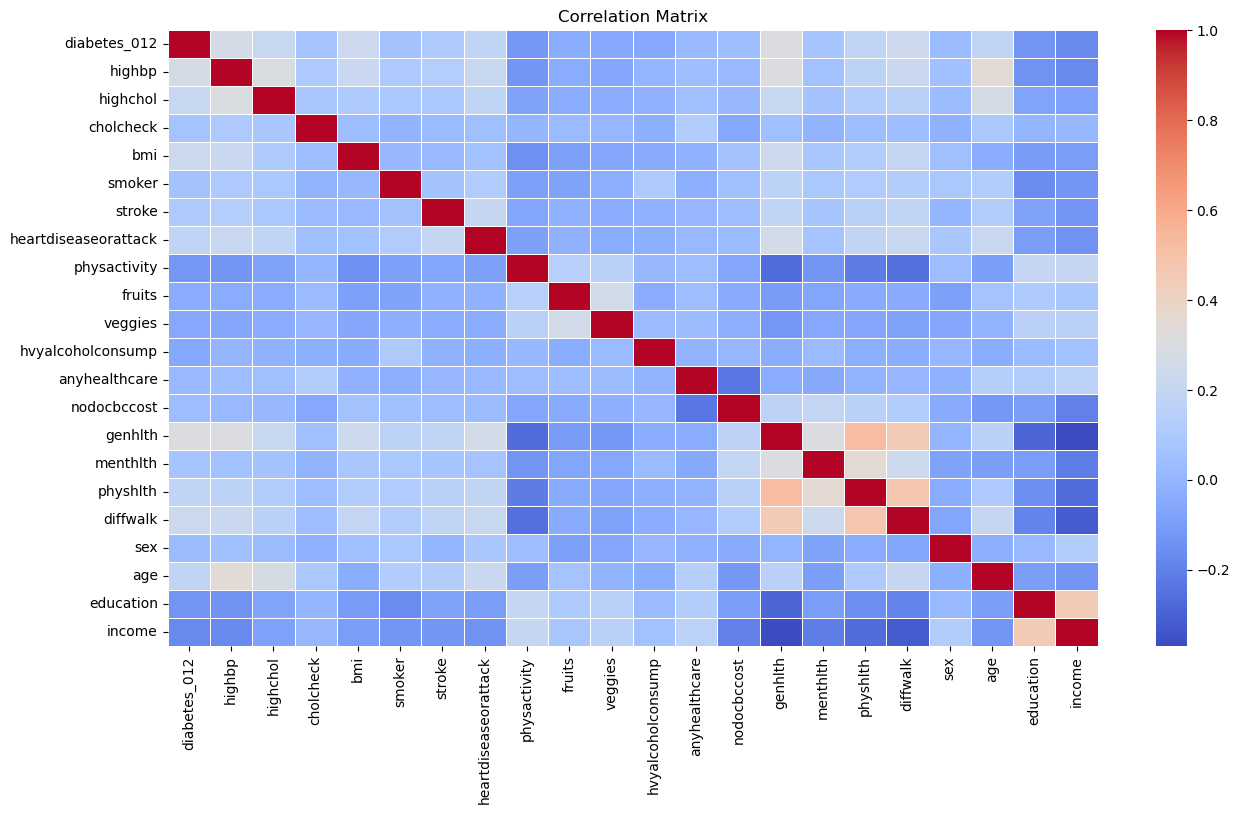

In [10]:
# Display Correlation Heat Map

plt.figure(figsize=(15, 8))
sns.heatmap(prediabetes_og.corr(),  cmap='coolwarm', linewidths=0.5) #annot=False - show colors but dont write numbers in the square
plt.title('Correlation Matrix')

plt.show()


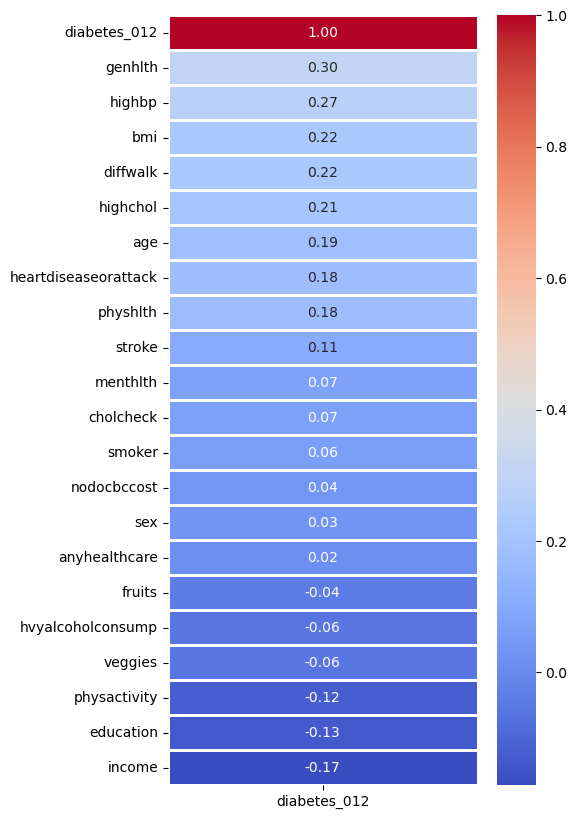

In [11]:
# Correlation Heat Map Simple
# Sort by target variable

plt.figure(figsize=(5, 10))
# Note to double bracket, expected dataframe for target diabetes_012
target_corr = prediabetes_og.corr()[['diabetes_012']].sort_values(by='diabetes_012', ascending=False)  

sns.heatmap(target_corr, annot=True, cmap='coolwarm', linewidth=1, fmt=".2f")
plt.show()


**Top Positive Correlation**

The graph shows the top-5 strongest positive correlation.
For initial screening, it helps to quickly identify which features have a linear relationship with the target variable.

- genhlth                   0.30
- highbp                    0.27
- bmi                       0.22
- diffwalk                  0.22
- highchol                  0.20

**Top Negative Correlation**

The top 3 negative correlation are:
- income                   -0.17
- education                -0.13
- physactivity             -0.12

Negative correlations represent as Protective Factors. These are the variables that defend a person against moving into the prediabetes class.


**Potential Noise**

These features have weak correlation and can be a candidate for feature pruning.
- nodocbccost               0.035436
- sex                       0.031040
- anyhealthcare             0.015410
- fruits                   -0.042192
- hvyalcoholconsump        -0.057882
- veggies                  -0.



&nbsp;

###  Inspection of colums, unique values and counts
- Inspect and verify columns
- Inspect values and counts for binary features 0 and 1, we can also catch if there are values like NaN or "Unknown"
- We can also see distribution of values

In [12]:
# List all column names to inspect for processing
prediabetes_og.columns

Index(['diabetes_012', 'highbp', 'highchol', 'cholcheck', 'bmi', 'smoker',
       'stroke', 'heartdiseaseorattack', 'physactivity', 'fruits', 'veggies',
       'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'genhlth',
       'menthlth', 'physhlth', 'diffwalk', 'sex', 'age', 'education',
       'income'],
      dtype='object')

In [13]:
# Check and verify unique values in each column that are out of range
print(prediabetes_og.nunique())

# Notice that our target 'diabetes_012' has 3 classes: (0)no diabetes or healthy, (1)prediabetes and (2)diabetes

diabetes_012             3
highbp                   2
highchol                 2
cholcheck                2
bmi                     84
smoker                   2
stroke                   2
heartdiseaseorattack     2
physactivity             2
fruits                   2
veggies                  2
hvyalcoholconsump        2
anyhealthcare            2
nodocbccost              2
genhlth                  5
menthlth                31
physhlth                31
diffwalk                 2
sex                      2
age                     13
education                6
income                   8
dtype: int64


Here we can see the unique values on each column, most of them are binary(0 and 1)
- bmi seems to be high and we can investigate further
- menthlth and physhlth seems to be ok, 31 are the number of days in a month
- genhlth, age, education and income seems to be ok, they were scaled in group

&nbsp;

### Target Distribution and Plot


In [14]:
# Target variable unique value and counts
prediabetes_og['diabetes_012'].value_counts()

# class 0 - healthy or no diabetes
# class 1 - prediabetes
# class 2 - diabetes

diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

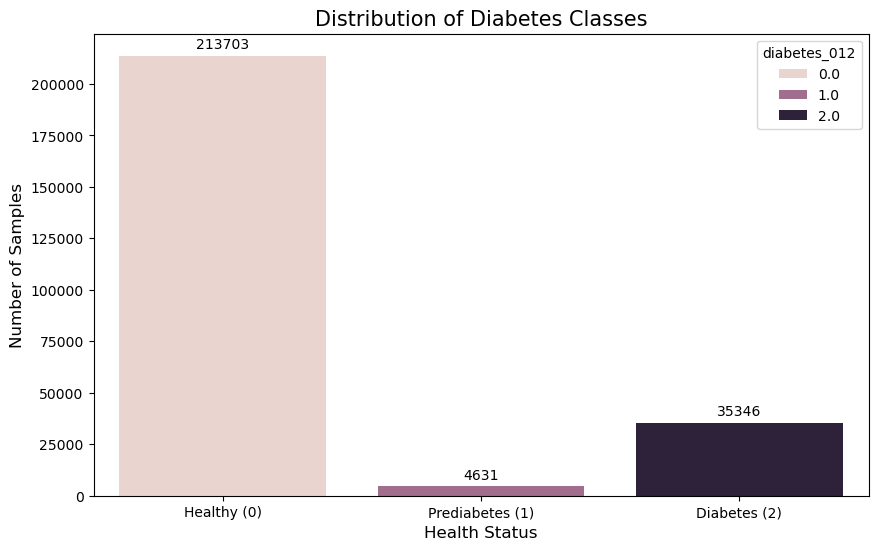

In [15]:
# Display Class Distribution of Target
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='diabetes_012', data=prediabetes_og, hue='diabetes_012')

# Ticks and labels 
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Healthy (0)', 'Prediabetes (1)', 'Diabetes (2)'])

# Counts on top of the bars
# Padding adds a little space
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)
ax.bar_label(ax.containers[2], padding=3)

plt.title('Distribution of Diabetes Classes', fontsize=15)
plt.xlabel('Health Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Save diabetes distribution image
plt.savefig('prediabetes_class_distribution.png')

- The graph shows our diabetes distribution and this is an extreme imbalance between the three classes
- Data shows that Healthy individuals outnumber Prediabetics by 46 is to 1.
- Data also shows that Healthy individuals outnumber Diabetics by 6 is to 1.
- In the world of data science, this is a "needle in a haystack" scenario.

In [16]:
# Unique values and count for High Blood Pressure
prediabetes_og['highbp'].value_counts()

highbp
0.0    144851
1.0    108829
Name: count, dtype: int64

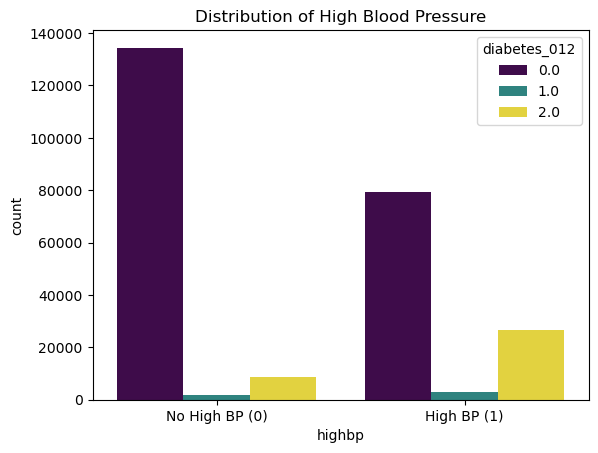

In [17]:
# Distribution plot for High Blood Pressure
ax = sns.countplot(x='highbp', data=prediabetes_og, hue='diabetes_012', palette='viridis')

# Ticks and labels 
ax.set_xticks([0, 1])
ax.set_xticklabels(['No High BP (0)', 'High BP (1)'])

plt.title('Distribution of High Blood Pressure')
plt.show()

- This graph shows the diabetes class breakdown for people with 'No High BP' and 'High BP'

In [18]:
# Unique values and count for High Cholesterol
prediabetes_og['highchol'].value_counts()  

highchol
0.0    146089
1.0    107591
Name: count, dtype: int64

In [19]:
# Unique values and count for Cholesterol Check
prediabetes_og['cholcheck'].value_counts()   

cholcheck
1.0    244210
0.0      9470
Name: count, dtype: int64

In [20]:
# Unique values and count for BMI
prediabetes_og['bmi'].value_counts()   

bmi
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
91.0        1
86.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64

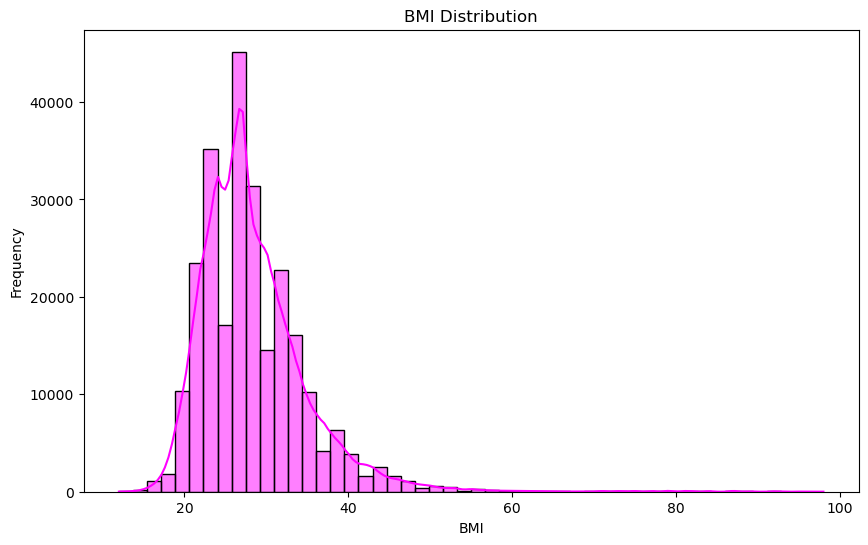

In [21]:
# Plot for BMI Distribution
plt.figure(figsize=(10, 6))
sns.histplot(prediabetes_og['bmi'], bins=50, kde=True, color='magenta')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

- This graph shows that the BMI distribution is Right-Skewed.
- Most people are in the 20–30 range, but there is a long tail of very high BMI values.
- We can then verify this later in our data cleaning process and consider removing BMI > 60 as outliers.

In [22]:
# Unique values and count for Smoker
prediabetes_og['smoker'].value_counts()   

smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

In [23]:
# Unique values and count for Stroke
prediabetes_og['stroke'].value_counts()   

stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

Text(0.5, 1.0, 'Diabetes Frequency based on Stroke History')

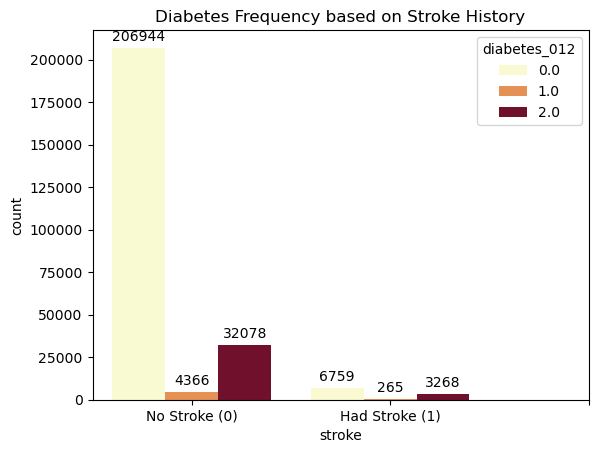

In [24]:
# Plotting Stroke and Diabetes
ax = sns.countplot(x='stroke', hue='diabetes_012', data=prediabetes_og, palette='YlOrRd') # 'viridis' "magma", or "YlOrRd"

# Ticks and labels 
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Stroke (0)', 'Had Stroke (1)'])

# Show counts on top of the bars
# padding adds a little space
ax.set_xticks([0, 1, 2])
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)
ax.bar_label(ax.containers[2], padding=3)

plt.title('Diabetes Frequency based on Stroke History')
# Optional: plt.legend(title='Condition', labels=['Healthy', 'Prediabetes', 'Diabetes']) otherwise use hue

- This graph shows the distribution of prediabetes with people who had 'No Stroke' and 'Had Stroke'.
- Among individuals who have had a stroke(10292), about 2.5% have prediabetes and 32% have diabetes.

In [25]:
# Unique values and count for Heart Disease
prediabetes_og['heartdiseaseorattack'].value_counts()   

heartdiseaseorattack
0.0    229787
1.0     23893
Name: count, dtype: int64

In [26]:
# Unique values and count for Physical Activity
prediabetes_og['physactivity'].value_counts()   

physactivity
1.0    191920
0.0     61760
Name: count, dtype: int64

In [27]:
# Unique values and count for Fruits
prediabetes_og['fruits'].value_counts()   

fruits
1.0    160898
0.0     92782
Name: count, dtype: int64

In [28]:
# Unique values and count for Veggies
prediabetes_og['veggies'].value_counts()   

veggies
1.0    205841
0.0     47839
Name: count, dtype: int64

In [29]:
# Unique values and count for heavy Alcohol Consumption
prediabetes_og['hvyalcoholconsump'].value_counts()   

hvyalcoholconsump
0.0    239424
1.0     14256
Name: count, dtype: int64

In [30]:
# Unique values and count for No doctor because of cost
prediabetes_og['nodocbccost'].value_counts()   

nodocbccost
0.0    232326
1.0     21354
Name: count, dtype: int64

In [31]:
# Unique values and count for General Health
prediabetes_og['genhlth'].value_counts()   

genhlth
2.0    89084
3.0    75646
1.0    45299
4.0    31570
5.0    12081
Name: count, dtype: int64

In [32]:
# Show percentages for General Health

print(prediabetes_og['genhlth'].value_counts(normalize=True) * 100)   #Percentage

# 1 - excellent 
# 5 - poor

genhlth
2.0    35.116682
3.0    29.819458
1.0    17.856749
4.0    12.444812
5.0     4.762299
Name: proportion, dtype: float64


In [33]:
# Mental Health - how many days during the past 30 days was your mental health not good? scale 1-30 days
# Unique values and count
prediabetes_og['menthlth'].value_counts().sort_index()

# Note that there are individuals who reported high numbers -30 days - it often indicates chronic stress and depression

menthlth
0.0     175680
1.0       8538
2.0      13054
3.0       7381
4.0       3789
5.0       9030
6.0        988
7.0       3100
8.0        639
9.0         91
10.0      6373
11.0        41
12.0       398
13.0        41
14.0      1167
15.0      5505
16.0        88
17.0        54
18.0        97
19.0        16
20.0      3364
21.0       227
22.0        63
23.0        38
24.0        33
25.0      1188
26.0        45
27.0        79
28.0       327
29.0       158
30.0     12088
Name: count, dtype: int64

In [34]:
# Unique values and count for Physical Health
# Physical Health - For how many days during the past 30 days was your physical health not good? scale 1-30 days	
prediabetes_og['physhlth'].value_counts().sort_index()

physhlth
0.0     160052
1.0      11388
2.0      14764
3.0       8495
4.0       4542
5.0       7622
6.0       1330
7.0       4538
8.0        809
9.0        179
10.0      5595
11.0        60
12.0       578
13.0        68
14.0      2587
15.0      4916
16.0       112
17.0        96
18.0       152
19.0        22
20.0      3273
21.0       663
22.0        70
23.0        56
24.0        72
25.0      1336
26.0        69
27.0        99
28.0       522
29.0       215
30.0     19400
Name: count, dtype: int64

In [35]:
# Unique values and count for Difficulty Walking
# Do you have serious difficulty walking or climbing stairs? 
prediabetes_og['diffwalk'].value_counts()

diffwalk
0.0    211005
1.0     42675
Name: count, dtype: int64

In [36]:
# Unique values and count for Sex
prediabetes_og['sex'].value_counts()

sex
0.0    141974
1.0    111706
Name: count, dtype: int64

In [37]:
# Age group - 13-level age category 
# Unique values and count
prediabetes_og['age'].value_counts().sort_index()

age
1.0      5700
2.0      7598
3.0     11123
4.0     13823
5.0     16157
6.0     19819
7.0     26314
8.0     30832
9.0     33244
10.0    32194
11.0    23533
12.0    15980
13.0    17363
Name: count, dtype: int64

In [38]:
# Education group - Scale 1 to 6
# Unique values and count
prediabetes_og['education'].value_counts()

education
6.0    107325
5.0     69910
4.0     62750
3.0      9478
2.0      4043
1.0       174
Name: count, dtype: int64

In [39]:
# Income group - Income scale 1-8
# Unique values and count
prediabetes_og['income'].value_counts()

income
8.0    90385
7.0    43219
6.0    36470
5.0    25883
4.0    20135
3.0    15994
2.0    11783
1.0     9811
Name: count, dtype: int64

### Distribution Plot for each Feature Columns

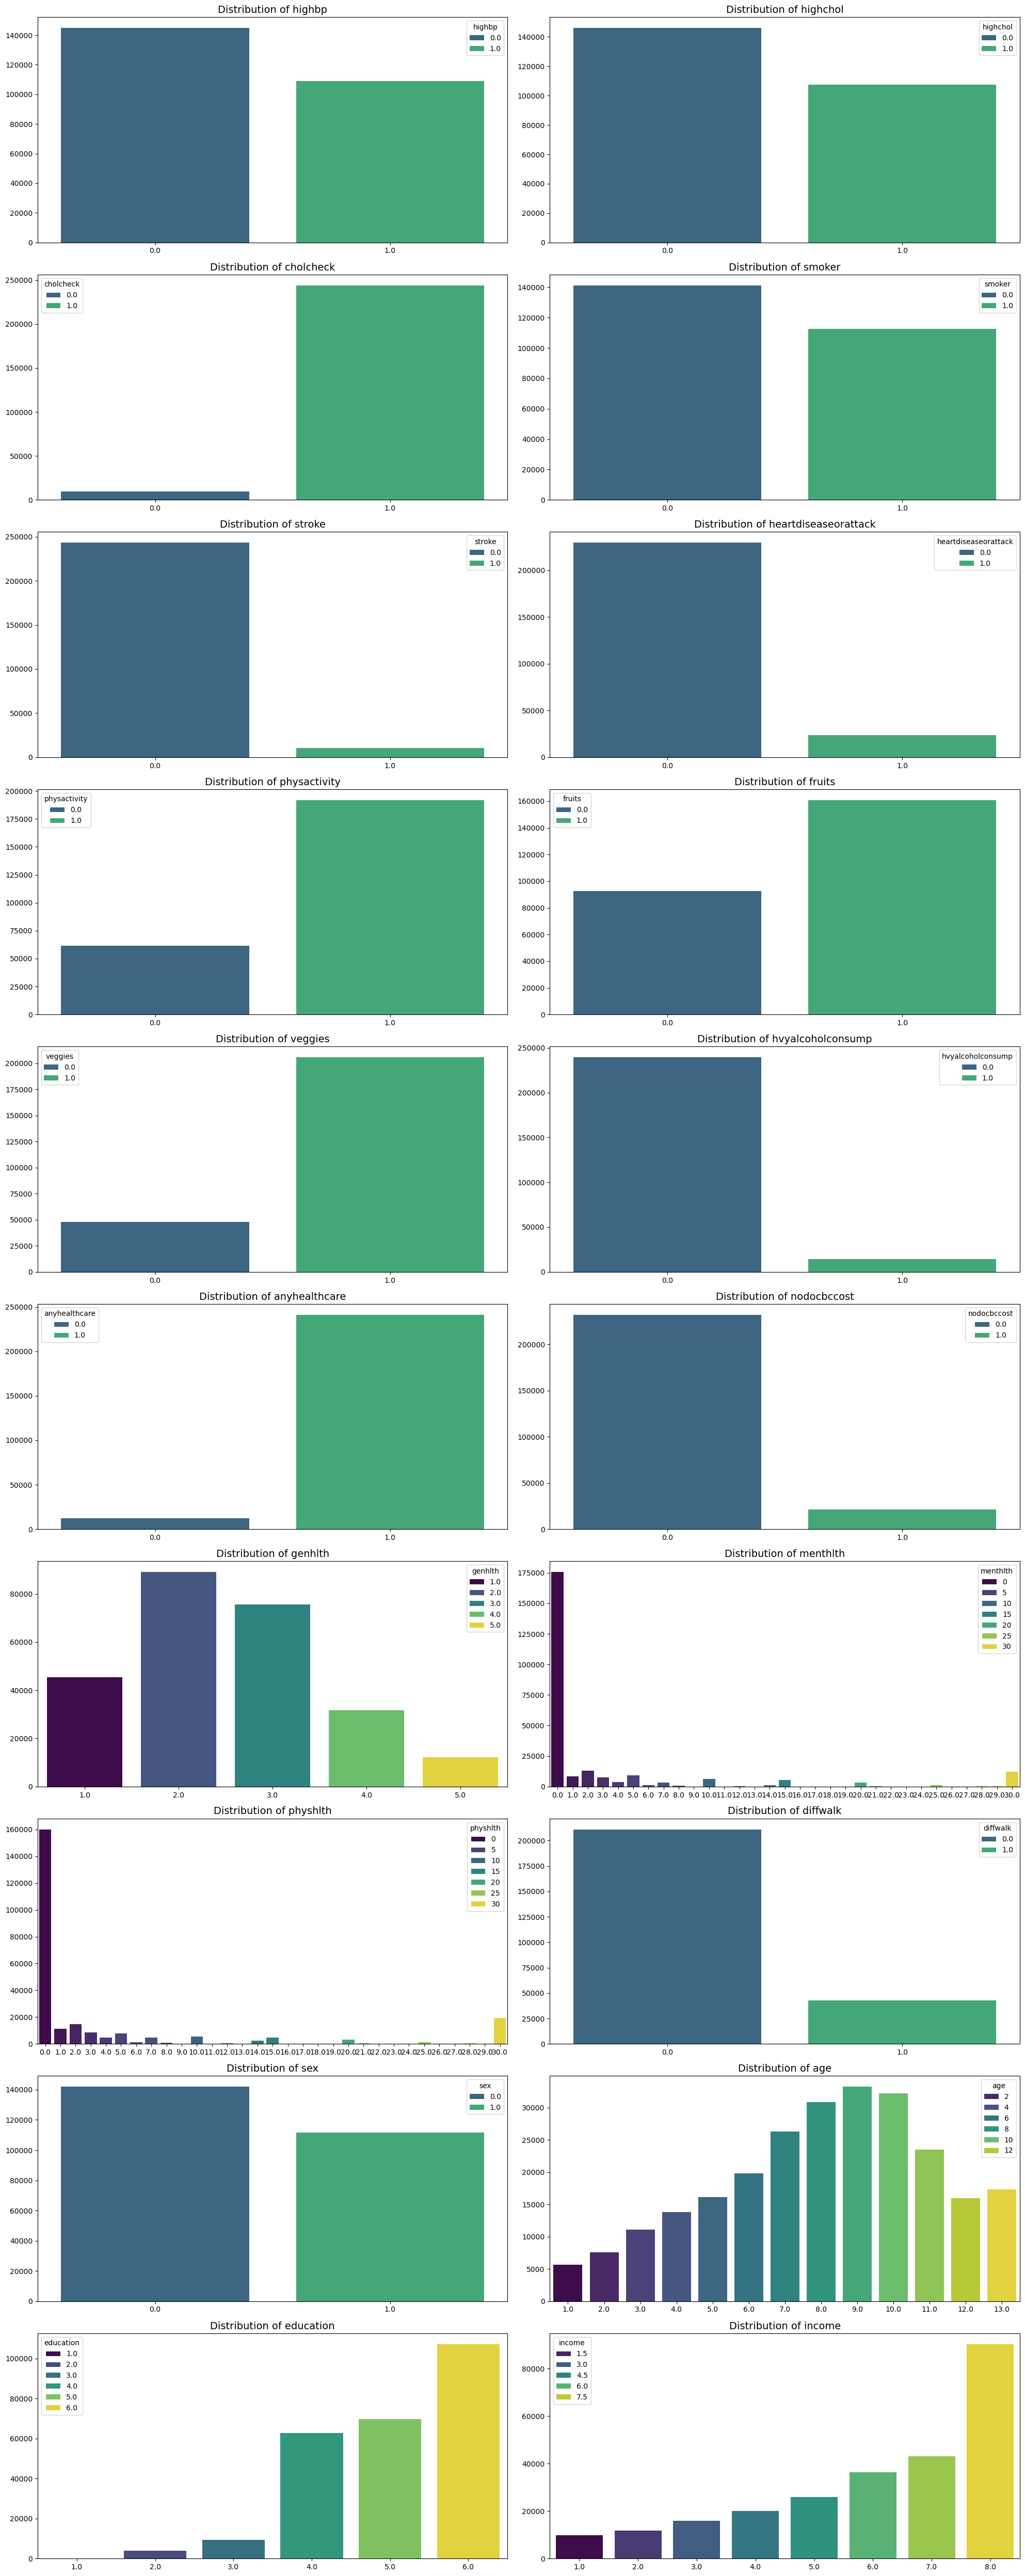

In [40]:
# Distribution Subplots for Features
# List of all columns except target variable and BMI distribution 
cols_to_plot = [col for col in prediabetes_og.columns if col not in ['diabetes_012','bmi']]

# Grid Subplots
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(20, 50))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(x=col, data=prediabetes_og, ax=axes[i], hue=col, palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

- Looking at the binary features: cholesterol , stroke, heart disease attack, heavy alcohol consumption, any healthcare and difficulty walking are highly imbalance.
- Income is a primary determinant of health and higher education correlates wiht higher health literacy.

### 4. Data Cleaning and Preprocessing


In [41]:
# Check for missing values
prediabetes_og.isna().sum()


diabetes_012            0
highbp                  0
highchol                0
cholcheck               0
bmi                     0
smoker                  0
stroke                  0
heartdiseaseorattack    0
physactivity            0
fruits                  0
veggies                 0
hvyalcoholconsump       0
anyhealthcare           0
nodocbccost             0
genhlth                 0
menthlth                0
physhlth                0
diffwalk                0
sex                     0
age                     0
education               0
income                  0
dtype: int64

### Handling Duplicates

In [42]:
# Check for duplicates
prediabetes_og.duplicated().sum()

np.int64(23899)

In [43]:
# Show duplicates then verify
duplicates = prediabetes_og[prediabetes_og.duplicated(keep=False)]

# Sort to make it much easier to visually spot the duplicates
all_duplicates_sorted = duplicates.sort_values(by=list(prediabetes_og.columns))

all_duplicates_sorted

,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72906,2.0,1.0,1.0,1.0,38.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,11.0,6.0,6.0
145095,2.0,1.0,1.0,1.0,38.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,10.0,5.0,8.0
150492,2.0,1.0,1.0,1.0,38.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,10.0,5.0,8.0
115752,2.0,1.0,1.0,1.0,39.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0


#### Inspect the duplicates that are affecting the target classes before dropping 
- In this section we will investigate if the duplicates are greatly affecting our target distribution before dropping them

In [44]:
# Check distribution of the target variable with duplicates

print(duplicates['diabetes_012'].value_counts(normalize=True))    # proportion

# Class 1 is Prediabetes

diabetes_012
0.0    0.986234
2.0    0.013652
1.0    0.000114
Name: proportion, dtype: float64


#### Drop Duplicates

In [45]:
# Drop the duplicates 

# The proportion shows that majority of the duplicates are in the 'Healthy' class 0 and Diabetic Class 2 which is a good thing
# For the 'Prediabetes' Class 1, it has almost no duplicates (0.0001), we can then safely drop them
# We will then reassign the clean version to a new DataFrame

prediabetes_clean = prediabetes_og.drop_duplicates()


In [46]:
# Verify duplicates after dropping
prediabetes_clean.isnull().sum()

diabetes_012            0
highbp                  0
highchol                0
cholcheck               0
bmi                     0
smoker                  0
stroke                  0
heartdiseaseorattack    0
physactivity            0
fruits                  0
veggies                 0
hvyalcoholconsump       0
anyhealthcare           0
nodocbccost             0
genhlth                 0
menthlth                0
physhlth                0
diffwalk                0
sex                     0
age                     0
education               0
income                  0
dtype: int64

### Handling Outliers
- BMI

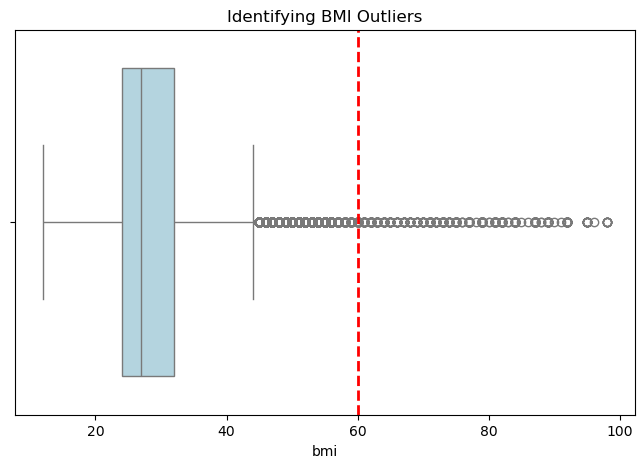

In [47]:
# Check BMI feature for outliers 
plt.figure(figsize=(8, 5))
sns.boxplot(x=prediabetes_clean['bmi'], color='lightblue')

# Vertical line at 60 BMI 
plt.axvline(x=60, color='red', linestyle='--', linewidth=2, label='BMI = 60')

plt.title('Identifying BMI Outliers')
plt.show()

Notes: 
- BMI is calculated as: BMI =  weight / height
- A BMI of 80–99 is extremely high and rare.

Example: 
5'5" (65 inches)

BMI 80: ~480 lbs

BMI 99: ~594 lbs

In medical terminology, a BMI over 60 is considered "super-super obese." Whether someone has a BMI of 65 or 95, their risk profile is effectively the same.
We will then use 60 as our 'cutoff', this is the maximum level of risk for the BMI feature.


In [48]:
# Check how many people have a BMI over 60
count = len(prediabetes_clean[prediabetes_clean['bmi'] > 60])
print(f"Number of People with BMI > 60: {count}")
print(f"In Percentage: {(count / len(prediabetes_clean)) * 100:.2f}%")


Number of People with BMI > 60: 805
In Percentage: 0.35%


In [49]:
# Extreme BMI Removal
# We will remove people over 60 BMI, they are considered outliers. 
# If percentage < 1% , it is safe to remove or cap them at 60. 
# Resave it back to DataFrame
prediabetes_clean = prediabetes_clean[prediabetes_clean['bmi'] <= 60]


In [50]:
# Verify BMI outlier removal
count = len(prediabetes_clean[prediabetes_clean['bmi'] > 60])
print(f"Number of People with BMI > 60: {count}")


Number of People with BMI > 60: 0


In [51]:
# Review new shape after data cleaning
prediabetes_clean['bmi'].shape


(228976,)

In [52]:
# Show columns Before Feature Engineering
# 22 Features
prediabetes_clean.columns

Index(['diabetes_012', 'highbp', 'highchol', 'cholcheck', 'bmi', 'smoker',
       'stroke', 'heartdiseaseorattack', 'physactivity', 'fruits', 'veggies',
       'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'genhlth',
       'menthlth', 'physhlth', 'diffwalk', 'sex', 'age', 'education',
       'income'],
      dtype='object')

### 5. Feature Engineering

#### Copy Dataframe For Experimental Change

In [53]:
# .copy(). This protects the master dataset from the experimental feature interactions that we are going add
prediabetes_df = prediabetes_clean.copy()	


#### Feature Interactions

In [54]:
# Metabolic Index: High BMI + General Health + Age
prediabetes_df['metabolic_index'] =  prediabetes_df['bmi'] * prediabetes_df['genhlth'] * prediabetes_df['age']


In [55]:
# Stress Score: Low Income + Low Education + Mental Health
prediabetes_df['stress_score'] = (prediabetes_df['menthlth'] + 1) / (prediabetes_df['income'] * prediabetes_df['education'])


In [56]:
# Physical Fragility Decline: Physical Health + DiffWalk + Age
prediabetes_df['physical_fragility'] = prediabetes_df['physhlth'] * prediabetes_df['diffwalk'] * prediabetes_df['age']
       

In [57]:
# Early Warning: Captures people with high BMI who DON'T have a high blood pressure yet (early stage)
prediabetes_df['early_warning'] = ((prediabetes_df['bmi'] > 25) & 
                                   (prediabetes_df['highbp'] == 0)).astype(int)

In [58]:
# Pre-Risk Zone: Captures the 'Warning' stage rather than the 'Chronic' stage
prediabetes_df['pre_risk_zone'] = ((prediabetes_df['bmi'] >= 25) & 
                                   (prediabetes_df['highbp'] == 1) & 
                                   (prediabetes_df['highchol'] == 0)).astype(int)

#### Feature Binning 
Overweight(BMI 25–29.9) to Obese(BMI ≥ 30)
- Overweight (BMI 25–29.9) - Insulin resistance can begin on this range.
- Obese (BMI ≥ 30) - Risk of insulin resistance increases substantially. Much higher chance of Prediabetes and Type 2 diabetes.


In [59]:
# BMI Hierarchy of Risk Level
# Create different BMI ranges
prediabetes_df['bmi_risk_level'] = 0 # Normal
prediabetes_df.loc[(prediabetes_df['bmi'] >= 25) & (prediabetes_df['bmi'] < 30), 'bmi_risk_level'] = 1       #for overweight bmi between 25 to 29
prediabetes_df.loc[(prediabetes_df['bmi'] >= 30), 'bmi_risk_level'] = 2                                      #for obese bmi over 30


In [60]:
# Display the new DataFrame with the new feature engineering
prediabetes_df.head(5)


,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,sex,age,education,income,metabolic_index,stress_score,physical_fragility,early_warning,pre_risk_zone,bmi_risk_level
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,9.0,4.0,3.0,1800.0,1.583333,135.0,0,0,2
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,7.0,6.0,1.0,525.0,0.166667,0.0,0,0,1
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,0.0,9.0,4.0,8.0,1260.0,0.968750,270.0,0,0,1
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,11.0,3.0,6.0,594.0,0.055556,0.0,0,1,1
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,11.0,5.0,4.0,528.0,0.200000,0.0,0,0,0


### Final Correlation with Feature Interactions

In [61]:
# Recalculate correlation with the target variable and how they are
correlations = prediabetes_df.corr()['diabetes_012'].sort_values(ascending=False)

print(correlations)

diabetes_012            1.000000
metabolic_index         0.375739
genhlth                 0.284223
highbp                  0.261628
bmi                     0.231282
diffwalk                0.209397
bmi_risk_level          0.204223
highchol                0.203393
age                     0.184894
physical_fragility      0.171545
heartdiseaseorattack    0.170710
physhlth                0.159256
stroke                  0.100307
stress_score            0.081677
cholcheck               0.075732
menthlth                0.057187
pre_risk_zone           0.051172
smoker                  0.046813
sex                     0.032643
anyhealthcare           0.024977
nodocbccost             0.023294
fruits                 -0.025254
veggies                -0.043142
hvyalcoholconsump      -0.067088
physactivity           -0.102543
education              -0.107464
early_warning          -0.117472
income                 -0.146330
Name: diabetes_012, dtype: float64


Base on the correlation score, we have achived good results on our new feature interactions: 

- Positive Good interactions
    - metabolic_index         0.375739
    - bmi_risk_level          0.204223
    - physical_fragility      0.171545
    - The new metabolic_index (0.37) is outperforming our previous top feature, genhlth (0.28), by a massive margin.

- Negative Top Interaction 
    - early_warning          -0.117472
    - Early warnings also becomes a best negative protector 

- Weak feature interaction 
    - stress_score
    - pre_risk_zone 



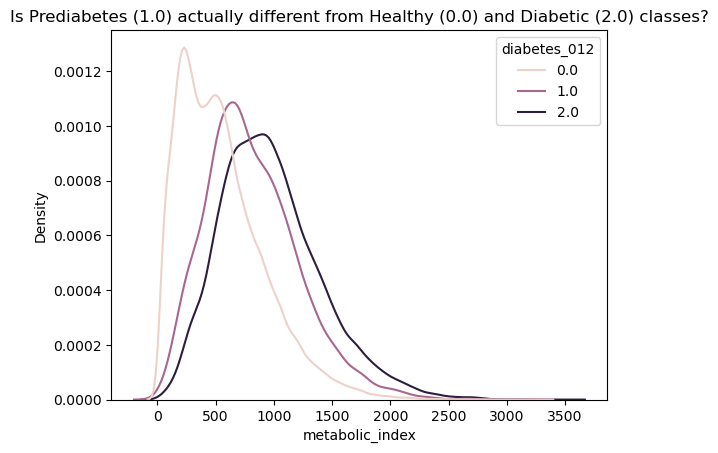

In [62]:
# Plot Distribution of your top feature if prediabetes class is being detected
sns.kdeplot(data=prediabetes_df, x='metabolic_index', hue='diabetes_012', common_norm=False)
plt.title("Is Prediabetes (1.0) actually different from Healthy (0.0) and Diabetic (2.0) classes?")
plt.show()

- This graph compares the distribution of metabolic index values across the three classes (healthy, prediabetes, and diabetes).
- Notice that the Prediabetes(middle) class's hump of the curve clearly overlaps between the Healthy and Diabetic class.

In [63]:
# Check DataFrame shape after Data Cleaning process
# Original 253680
prediabetes_df.shape


(228976, 28)

In [64]:
# Final verfication for missing values before Splitting 
prediabetes_df.isna().sum()


diabetes_012            0
highbp                  0
highchol                0
cholcheck               0
bmi                     0
smoker                  0
stroke                  0
heartdiseaseorattack    0
physactivity            0
fruits                  0
veggies                 0
hvyalcoholconsump       0
anyhealthcare           0
nodocbccost             0
genhlth                 0
menthlth                0
physhlth                0
diffwalk                0
sex                     0
age                     0
education               0
income                  0
metabolic_index         0
stress_score            0
physical_fragility      0
early_warning           0
pre_risk_zone           0
bmi_risk_level          0
dtype: int64

In [65]:
# Dataframe columns with new feature interactions before split
prediabetes_df.columns


Index(['diabetes_012', 'highbp', 'highchol', 'cholcheck', 'bmi', 'smoker',
       'stroke', 'heartdiseaseorattack', 'physactivity', 'fruits', 'veggies',
       'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'genhlth',
       'menthlth', 'physhlth', 'diffwalk', 'sex', 'age', 'education', 'income',
       'metabolic_index', 'stress_score', 'physical_fragility',
       'early_warning', 'pre_risk_zone', 'bmi_risk_level'],
      dtype='object')

&nbsp;

### 6. Data Splitting


### Input and Target Variable

In [66]:
# Input Features
X = prediabetes_df.drop(['diabetes_012'], axis=1)   

# Target variable
y = prediabetes_df['diabetes_012']

### Train Test Split

In [67]:
# Split the data with 20% for testing
# 'stratify=y' is vital to keep the prediabetes ratio consistent in both sets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


### Examine target variable after Split

In [68]:
# Class Distribution of Target imbalance after train/test split

# Train set
y_train.value_counts()

diabetes_012
0.0    151550
2.0     27941
1.0      3689
Name: count, dtype: int64

In [69]:
# Test set
y_test.value_counts()

diabetes_012
0.0    37888
2.0     6985
1.0      923
Name: count, dtype: int64

### Scaling and Preprocessor
- We don’t scale binary features because they are already in their most perfect format for a machine learning model.
- It is completely normal and expected to have negative values after scaling.


In [70]:
# Verify which features column are needed to scale. 
# We can exclude binary columns with 1 and 0. 
X.head()


,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,veggies,...,sex,age,education,income,metabolic_index,stress_score,physical_fragility,early_warning,pre_risk_zone,bmi_risk_level
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,9.0,4.0,3.0,1800.0,1.583333,135.0,0,0,2
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,7.0,6.0,1.0,525.0,0.166667,0.0,0,0,1
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,9.0,4.0,8.0,1260.0,0.968750,270.0,0,0,1
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,11.0,3.0,6.0,594.0,0.055556,0.0,0,1,1
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,11.0,5.0,4.0,528.0,0.200000,0.0,0,0,0


In [71]:
# Scaling : Columns to Scale

# V1: With Feature Interactions
# Original Features to Scale = 'bmi', 'genhlth', 'menthlth', 'physhlth','age', 'education', 'income'
# Feature Interaction to Scale: 'metabolic_index', 'stress_score', 'physical_fragility', 'bmi_risk_level'

scale_cols = ['bmi', 'genhlth', 'menthlth', 'physhlth','age', 'education', 'income', 'metabolic_index', 'stress_score', 'physical_fragility', 'bmi_risk_level']


# Preprocessor: Scales only the continuous/ordinal columns
preprocessor = ColumnTransformer(
    transformers=[('numscale', StandardScaler(), scale_cols)],
    remainder='passthrough'
)

&nbsp;

### Handling Imbalance

### SMOTE and RandomUnderSampler
- SMOTE and Undersampling should only change the training set, not the test set.

In [72]:
# Setup Resampling Targets and Size
# Examine the classes in y_train from split
train_counts = Counter(y_train)
train_counts


Counter({0.0: 151550, 2.0: 27941, 1.0: 3689})

In [73]:
# Set sizes for Prediabetes and Healthy classs
prediabetes_count = int(train_counts[0.0] * 0.2)     # Prediabetes count to be 20% of the original(151550) Healthy class 0 count 
healthy_count = int(prediabetes_count * 2)           # Undersample Healthy count to be twice of Prediabetes count

print("New Prediabetes class count: ", prediabetes_count)
print("New Healthy class count: ", healthy_count)


New Prediabetes class count:  30310
New Healthy class count:  60620


In [74]:
# Set SMOTE for Prediabetes class 1
smote_sample = SMOTE(sampling_strategy={1: prediabetes_count}, random_state=42)                      #count 30310 #for Prediabetes
 
# Set RandomUnderSampler downsampling for Healthy class 0
under_sample = RandomUnderSampler(sampling_strategy={0: healthy_count}, random_state=42)             #count 60620 #for Healthy



- We did SMOTE on Prediabetes Class 1. Since the original Prediabetes Class 1 distribution is very small (4,631), SMOTE will be creating a lot of synthetic "Prediabetes" cases and brought it up closer to Class 2 (27,941)
  
- We did an UnderSampling on the Healthy Class 0 to be 2x the size of new Prediabetes Class 1. This will reduce the "Healthy" noise first. By setting it to 2x the size of the Prediabetes class, we still maintain a majority-class signal but prevent it from overwhelming the model.


&nbsp;

### 7. Model Selection

### DummyClassifier Stratified        
- for Baseline model

In [75]:
# DummyClassifier
# Set strategy="stratified" to get a baseline that at least tries to guess the other classes.
dummy_clf = DummyClassifier(strategy="stratified")

# Train and Predict
dummy_clf.fit(X_train, y_train) 
y_pred_dummy = dummy_clf.predict(X_test)

# Classification Report
print("--- DummyClassifier Baseline Report ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))


--- DummyClassifier Baseline Report ---
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83     37888
         1.0       0.01      0.02      0.02       923
         2.0       0.16      0.15      0.16      6985

    accuracy                           0.71     45796
   macro avg       0.33      0.33      0.33     45796
weighted avg       0.71      0.71      0.71     45796



- The stratified DummyClassifier baseline reveals a significant class imbalance. While the baseline shows a deceptive overall accuracy of 71%, its failure to capture more than 3% of at-risk Prediabete class underscores the necessity of our optimized Logistic Regression approach.

### Logistic Regression Default Baseline

In [76]:
# Logistic Regression Baseline

# Start the timer
start_time = time.time()

# multi_class='multinomial' parameter was deprecated and model handles automatically

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),        #Scale
    ('classifier', LogisticRegression(
        solver='lbfgs', 
        max_iter=1000, 
        random_state=42
    ))
])

# Train and Predict using Pipeline
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)


# Classification Report
print("--- Logistic Regression Baseline Report---")

# Set zero_division=0 to treat cases as 0 precision to avoid error
print(classification_report(y_test, y_pred_logreg, zero_division=0))

# Training Timer
timer = time.time() - start_time
print ("Timer (sec): ", timer)

#4.45 secs

--- Logistic Regression Baseline Report---
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     37888
         1.0       0.00      0.00      0.00       923
         2.0       0.54      0.18      0.27      6985

    accuracy                           0.83     45796
   macro avg       0.46      0.39      0.39     45796
weighted avg       0.79      0.83      0.79     45796

Timer (sec):  5.800387144088745


- Looking at Class 1, a recall of 0.00 means the model caught zero out of the 923 prediabetic individuals. 
Next, we will set and apply SMOTE, Undersampling and weight to balance the data.

### LogisticRegression with ImbPipeline, SMOTE, Undersampling and Balanced Class Weight

In [77]:
# LogisticRegression with ImbPipeline, SMOTE, Undersampling and Balanced Class_Weight

# Start the timer
start_time = time.time()

# Logistic Regression Sampling
# Order: Scale -> Smote -> Undersample -> Model
# multi_class='multinomial' parameter was deprecated and model handles automatically

# Setting class weight balanced

lgr_pipeline = ImbPipeline(steps=[
    ('prep', preprocessor),                   #Scale
    #('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),    #Dropped since we added feature interactions, creates duplicate
    ('smotesample', smote_sample),            #SMOTE
    ('undersample', under_sample),            #RandomUnderSampler
    ('classifier', LogisticRegression(
        solver='lbfgs', 
        class_weight='balanced',              #Crucial for Class 1 Recall goal! #SMOTE and Undersampling do the balancing
        max_iter=1000,                        
        random_state=42
    ))    
])

# Train and Predict using Pipeline
lgr_pipeline.fit(X_train, y_train)
y_pred_logreg = lgr_pipeline.predict(X_test)

# Classification Report
print("--- Logistic Regression with Sampling Report ---")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

# Training Timer
timer = time.time() - start_time
print ("Timer (sec): ", timer)

#2.79 sec

--- Logistic Regression with Sampling Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.62      0.75     37888
         1.0       0.03      0.37      0.06       923
         2.0       0.37      0.54      0.44      6985

    accuracy                           0.60     45796
   macro avg       0.45      0.51      0.42     45796
weighted avg       0.84      0.60      0.69     45796

Timer (sec):  5.0593342781066895


- Class 1.0 Recall has improve to 0.37 and Precision is very low.

### 8. Hyperparameter Tuning and Grid Search


In [78]:
# Logistic Regression with Hyperparameter Tuning
# Remove PolynomialFeature since we added new feature interactions from our previous experiment

# Start the timer
start_time = time.time()

# Increase max_iter to 2000

lgr_pipeline = ImbPipeline(steps=[
    ('prep', preprocessor),                   #Scale
    #('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),        #Exclude since we added feature interactions, creates duplicate
    ('smotesample', smote_sample),            #SMOTE
    ('undersample', under_sample),            #RandomUnderSampler
    ('classifier', LogisticRegression( 
        solver='lbfgs',
        #class_weight='balanced',              #SMOTE and Undersampling do the balancing with class_weight='balanced'
        max_iter=2000,                         #Increase to 2000 from 1000
        random_state=42 ))    
])


# Define the grid of weights to test for classes [0.0, 1.0, 2.0]
# We keep class 0 at 1 and vary the weights for class 1 and class 2

param_grid = {
    'classifier__class_weight': [
        {0.0: 1, 1.0: 5, 2.0: 2},    # Increase Class 1 to 5     #Best
        {0.0: 1, 1.0: 8, 2.0: 3},    # Increase Class 1 to 8
        {0.0: 1, 1.0: 10, 2.0: 4}    # Higher
    ],
    'classifier__C': [0.01, 0.1, 1]  # Regularization check
}

# Setup the Grid Search
lgr_grid = GridSearchCV(
    lgr_pipeline, 
    param_grid, 
    cv=3, 
    scoring='recall_macro',     # Important: recall macro/weighted to account for all classes
    #scoring='f1_macro',        # This forces the model to balance Precision and Recall. Recall score got worst
    verbose=1
)

# Train and Predict
lgr_grid.fit(X_train, y_train)
y_pred_grid = lgr_grid.predict(X_test)

# Best Parameter
print(f"Best Weights: {lgr_grid.best_params_}")
print()

# Classification Report
print(classification_report(y_test, y_pred_grid, zero_division=0))

# Training Timer
timer = time.time() - start_time
print ("GridSearch Timer (sec): ", timer)

#110 sec

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Weights: {'classifier__C': 0.01, 'classifier__class_weight': {0.0: 1, 1.0: 5, 2.0: 2}}

              precision    recall  f1-score   support

         0.0       0.98      0.33      0.50     37888
         1.0       0.03      0.88      0.05       923
         2.0       0.53      0.08      0.14      6985

    accuracy                           0.31     45796
   macro avg       0.51      0.43      0.23     45796
weighted avg       0.89      0.31      0.43     45796

GridSearch Timer (sec):  86.99612927436829


- Class 1.0 Recall (0.88): Recall has greatly increase to 0.88. This is our best so far. We are catching almost all prediabetics.

- Class 0.0 Recall (0.33): Very Low. We are misclassifying 67% of healthy people as having a risk.

- Since our goal is a screening tool, a high Recall is our priority - catching those "invisible" cases is more important than a few false alarms. However, at 0.03 Precision, this suggests that the class overlap between Healthy and Prediabetic is extremely dense. 


&nbsp;

### 9. Model Validation-Testing, Evaluation and Interpretation


### Permutation Importance (Initial)
- We will use Permutation Importance to clean the noise, to see which features are actually helping and which one to drop.

In [79]:
# Permutation Importance

# Use the Best fitted model
best_model = lgr_grid.best_estimator_

# Calculate the Permutation Importance
# We use 'Recall' to see what drives that 0.88 score
# Use X_test and y_test to see how the model generalizes
result = permutation_importance(
    best_model,                      #lgr_grid.best_estimator_
    X_test, 
    y_test, 
    scoring='recall_macro',          
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# Get feature names from the pipeline
feature_names = best_model.named_steps['prep'].get_feature_names_out()


# DataFrame for easy sorting and viewing
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean
})

# Sort from Highest to Lowest and Display
importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)

print("--- Permutation Feature Importance (Recall Macro) ---")
print(importance_df[['Feature', 'Importance_Mean']].to_string(index=False))

--- Permutation Feature Importance (Recall Macro) ---
             Feature  Importance_Mean
                 age         0.031050
             genhlth         0.028757
            highchol         0.008801
                 bmi         0.008273
              highbp         0.007642
              income         0.005076
heartdiseaseorattack         0.004782
              stroke         0.003191
           cholcheck         0.002054
            diffwalk         0.001470
        physactivity         0.001152
       early_warning         0.000782
              smoker         0.000351
              fruits         0.000149
           education         0.000129
             veggies         0.000117
      bmi_risk_level        -0.000019
       pre_risk_zone        -0.000074
       anyhealthcare        -0.000177
        stress_score        -0.000214
         nodocbccost        -0.000369
                 sex        -0.000437
            physhlth        -0.000569
   hvyalcoholconsump        -0.000

- We will keep our positive core signals starting from age down to veggies.
- We will drop the negative dead weights, everything from bmi_risk_level down to physical_fragility.

In [80]:
# Filter out negative features that don't help the model
selected_features = importance_df[importance_df['Importance_Mean'] > 0]
print(selected_features[['Feature', 'Importance_Mean']].to_string(index=False))

             Feature  Importance_Mean
                 age         0.031050
             genhlth         0.028757
            highchol         0.008801
                 bmi         0.008273
              highbp         0.007642
              income         0.005076
heartdiseaseorattack         0.004782
              stroke         0.003191
           cholcheck         0.002054
            diffwalk         0.001470
        physactivity         0.001152
       early_warning         0.000782
              smoker         0.000351
              fruits         0.000149
           education         0.000129
             veggies         0.000117


In [81]:
# Save core features to list
core_features = selected_features['Feature'].tolist()

In [82]:
# Update X to only include significant features
X_train_final = X_train[core_features].copy()
X_test_final = X_test[core_features].copy()


### Fine-Tuning Grid, Update ColumnTransformer and Pipeline with the Core Features

In [83]:
# Quick view of core features
print(core_features)

['age', 'genhlth', 'highchol', 'bmi', 'highbp', 'income', 'heartdiseaseorattack', 'stroke', 'cholcheck', 'diffwalk', 'physactivity', 'early_warning', 'smoker', 'fruits', 'education', 'veggies']


In [84]:
# Logistic Regression with Permutation Tuning

# Strong permutations left: early warning
# Update features to rescale
core_scale_cols = ['age', 'genhlth', 'bmi', 'income', 'early_warning', 'education']
              
# Update preprocessor to select only core columns
new_preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), core_scale_cols)],
    remainder='passthrough'                                        
)

# Re-build using the New preprocessor and BEST grid settings
lgr_core_pipeline = ImbPipeline(steps=[
    ('prep', new_preprocessor),                   #Scale
    ('smotesample', smote_sample),            #SMOTE
    ('undersample', under_sample),            #RandomUnderSampler
    ('classifier', LogisticRegression( 
        solver='lbfgs',
        class_weight='balanced',              #SMOTE and Undersampling do the balancing with class_weight='balanced'
        max_iter=2000, 
        random_state=42 ))   
])

# Use the same param_grid
param_grid = {
    'classifier__class_weight': [
        {0.0: 1, 1.0: 5, 2.0: 2},    # Increase Class 1 to 5     #Best
        {0.0: 1, 1.0: 8, 2.0: 3},    # Increase Class 1 to 8
        {0.0: 1, 1.0: 10, 2.0: 4}    # Higher
    ],
    'classifier__C': [0.01, 0.1, 1]  # Regularization check
}

# Setup the Grid Search
lgr_core_grid = GridSearchCV(
    lgr_core_pipeline, 
    param_grid, 
    cv=3, 
    scoring='recall_macro',     # Important: recall macro/weighted to account for all classes
    #scoring='f1_macro',        # This forces the model to balance Precision and Recall. Recall score got worst
    verbose=1
)


In [85]:
# Start the timer
start_time = time.time()

# Refit and Predict with the new core features
lgr_core_grid.fit(X_train_final, y_train)
y_pred_final = lgr_core_grid.predict(X_test_final)

# Best Parameter
print()
print(f"Best Weights: {lgr_core_grid.best_params_}")
print()


print("--- Final Logistic Regression Report (with Permutation) ---")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Training Timer
timer = time.time() - start_time
print ("GridSearch Timer (sec): ", timer)

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Weights: {'classifier__C': 0.1, 'classifier__class_weight': {0.0: 1, 1.0: 5, 2.0: 2}}

--- Final Logistic Regression Report (with Permutation) ---
              precision    recall  f1-score   support

         0.0       0.98      0.33      0.49     37888
         1.0       0.03      0.90      0.05       923
         2.0       0.54      0.06      0.11      6985

    accuracy                           0.30     45796
   macro avg       0.52      0.43      0.22     45796
weighted avg       0.89      0.30      0.42     45796

GridSearch Timer (sec):  68.40276789665222


- **Metrics:** Recall (0.90), Precision (0.03), Accuracy (0.30)

- The DummyClassifier and the Logistic Regression Baseline model (without class weights) had 0.02% and 0% Recall respectively for Prediabetes because the classes were too imbalanced.
  
- The Final Model successfully captured 90% of all Prediabetic cases (Class 1.0). In a healthcare context, this high recall is the primary success metric, as it ensures that nearly all at-risk individuals are funneled into the clinical testing pipeline.

- Precision Trade-off: The low precision (0.03) for Class 1.0 is a direct result of the aggressive class weighting ($1.0: 5$). While this creates a high volume of false alarms among healthy individuals, the 0.98 precision for Class 0.0 confirms that when the model does label someone as "Healthy," it is almost certainly correct.



### Coefficients
- In Logistic Regression, the model assigns a weight (coefficient) to each feature. The magnitude of these coefficients tells us which factors push a patient toward a Prediabetes diagnosis.

In [86]:
# Coefficients

# Get best estimator
final_lgr = lgr_core_grid.best_estimator_.named_steps['classifier']

# Get core feature names
feature_names = lgr_core_grid.best_estimator_.named_steps['prep'].get_feature_names_out()

# Extract coefficients for Class 1.0 (Prediabetes) using index 1
# Index 0 = Healthy, Index 1 = Prediabetes, Index 2 = Diabetes
class1_coefs = final_lgr.coef_[1]

# Create a DataFrame and Sort
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': class1_coefs
}).sort_values(by='Coefficient', ascending=False)


# Clean the feature names
coef_df['Feature'] = coef_df['Feature'].str.split('__').str[-1]

# Verify
#print(coef_df)

print()
print("--- Top Risk Drivers for Class 1.0 (Positive Coefficients) ---")
print(coef_df[coef_df['Coefficient'] > 0].to_string(index=False))

print("\n--- Top Protective Factors for Class 1.0 (Negative Coefficients) ---")
print(coef_df[coef_df['Coefficient'] < 0].to_string(index=False))


--- Top Risk Drivers for Class 1.0 (Positive Coefficients) ---
      Feature  Coefficient
    cholcheck     0.426393
     highchol     0.201575
          age     0.129643
          bmi     0.093362
      veggies     0.078278
      genhlth     0.061400
 physactivity     0.037357
       highbp     0.036018
early_warning     0.024605
       fruits     0.007351

--- Top Protective Factors for Class 1.0 (Negative Coefficients) ---
             Feature  Coefficient
           education    -0.022792
              smoker    -0.036652
              income    -0.077260
            diffwalk    -0.114839
heartdiseaseorattack    -0.265045
              stroke    -0.325216


**Strong Predictors:**
- cholcheck (0.426) & highchol (0.201) are the strongest predictors.
This makes sense for a prediabetes filter, as lipid panels and blood sugar issues often travel together (Metabolic Syndrome).

- age (0.129) & bmi (0.093) are also a steady and reliable "baseline" risks.

**Protective Predictors:**
- stroke (-0.325) & heartdiseaseorattack (-0.265) are the strong negative predictors. It means that patients with these severe conditions are being pushed into Class 2.0 (Full Diabetes).

**Feature Interaction:**
- The early_warning feature is the only feature interaction left from our previous build of interactions and it prove a successful piece of Feature Engineering.

&nbsp;

### Random Forest Classifier Experiment

In [87]:
# Random Forest

# Clange classifier in the pipeline
rf_core_pipeline = ImbPipeline(steps=[
    ('prep', new_preprocessor),
    ('smotesample', smote_sample),
    ('undersample', under_sample),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Param Grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__class_weight': [{0.0: 1, 1.0: 5, 2.0: 2}, 'balanced']
}

# Set up GridSearch
rf_grid = GridSearchCV(rf_core_pipeline, 
                       rf_param_grid, cv=3, 
                       scoring='recall_macro', 
                       verbose=1)

# Start the timer
start_time = time.time()

# Train and Predict
rf_grid.fit(X_train_final, y_train)
y_pred_rf = rf_grid.predict(X_test_final)

# Best Parameter
print()
print(f"Best Weights: {rf_grid.best_params_}")
print()

# Classification Report
print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Training Timer
timer = time.time() - start_time
print ("GridSearch Timer (sec): ", timer)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Weights: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 200}

--- Random Forest Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     37888
         1.0       0.03      0.06      0.04       923
         2.0       0.31      0.75      0.44      6985

    accuracy                           0.68     45796
   macro avg       0.43      0.50      0.42     45796
weighted avg       0.82      0.68      0.72     45796

GridSearch Timer (sec):  532.0920805931091


- Random Forest's Class 1.0 Recall sank to 0.06 and Precision stays at 0.03.
- Even though Random Forest is a more "powerful" non-linear model, it failed to maintain the sensitivity needed for Prediabetes Class 1.0. The Logistic Regression’s linear approach was more robust for this specific screening task because medical risk often follows a predictable, additive path.

### Confusion Matrix and ROC AUC For Logistic Regression

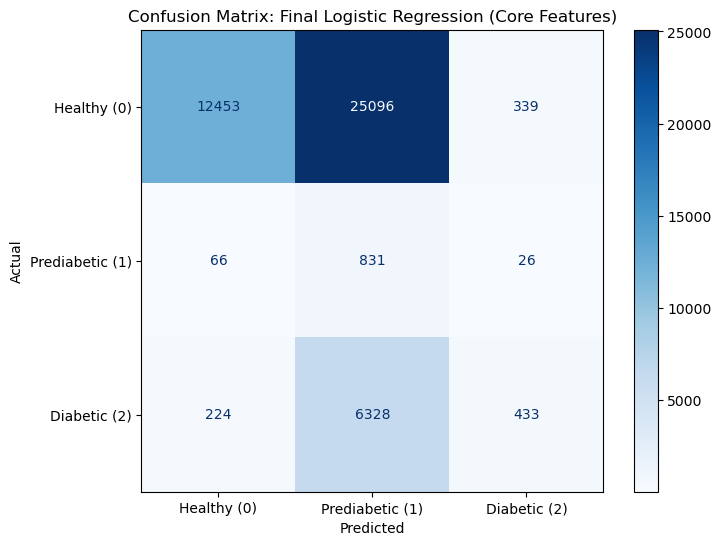

In [88]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)    # Use Logistic Regression prediction with core features

# Plot specific healthcare class with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Healthy (0)', 'Prediabetic (1)', 'Diabetic (2)'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')    # 'd' displays raw integers

plt.title('Confusion Matrix: Final Logistic Regression (Core Features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Save image
plt.savefig('confusion_matrix_logreg.png')

plt.show()

- Success (Middle Center): Look at the intersection of Actual 1 / Predicted 1. The model caught 831 Prediabetic (90% of 923 Class 1 samples).

- (Bottom Center): Since the model has low recall for Class 2.0 (Diabetes), Diabetic people are being "caught" as Prediabetics. This is a good thing in a screening tool, it means they still get flagged for medical attention.

- (Top Center): This is where the 0.03 Precision comes from. There are likely over 25,000 of healthy people being told they are at risk.

### ROC (Receiver Operating Characteristic) curve for Class 1.0

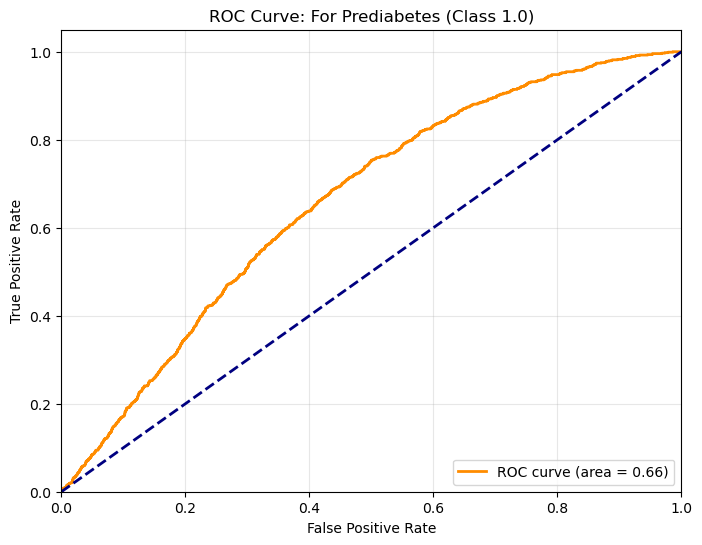

ROC AUC for Class 1.0: 0.6594


In [89]:
# Use predicted probabilities for all classes
# Results in an array with 3 columns [Class 0, Class 1, Class 2]
y_probs = lgr_core_grid.predict_proba(X_test_final)

# Get Prediabetes Class 1.0 probabilities (Index 1)
# and create a binary (1 if Class 1.0, 0 otherwise)
class1_probs = y_probs[:, 1]
y_test_binary = (y_test == 1.0).astype(int)

# Compute ROC for Class 1 (Prediabetes)
fpr, tpr, thresholds = roc_curve(y_test_binary, class1_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: For Prediabetes (Class 1.0)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save image
plt.savefig('roc_curve_prediabetes.png')

plt.show()

print(f"ROC AUC for Class 1.0: {roc_auc:.4f}")


- The Logistic Regression model achieved a moderate ROC AUC of 0.6594 for the Prediabetes class.

- A DummyClassifier or random-guess model would have an AUC of 0.50. Our Logistic Regression is significantly higher.

- The blue Diagonal Line represents the random guess(AUC = 0.50).

- The Curve: The further the curve "bows" toward the top-left corner, the better the model is at distinguishing between someone with prediabetes and someone without, regardless of the class weights.


### Final Permutation Feature Importance

In [90]:
# Permutation Importance (Final)
# Latest 'lgr_core_grid' which has the final feature set
best_model = lgr_core_grid.best_estimator_

# Calculate Permutation Importance
# We use 'recall_macro' to see what drives that 0.90 score
result = permutation_importance(
    best_model, 
    X_test_final,                #Final, cleaned test set
    y_test, 
    scoring='recall_macro', 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# DataFrame for easy sorting and viewing
importance_df = pd.DataFrame({
    'Feature': X_test_final.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)



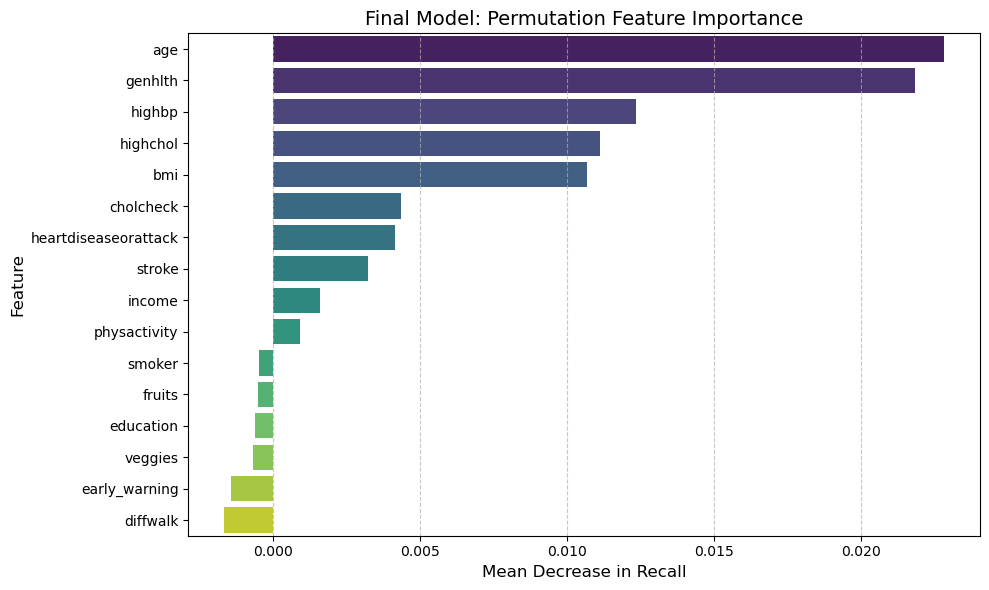

In [91]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance_Mean', 
    y='Feature', 
    data=importance_df,
    hue='Feature',
    palette='viridis'
)

# Title
plt.title('Final Model: Permutation Feature Importance', fontsize=14)
plt.xlabel('Mean Decrease in Recall', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save image
plt.savefig('permutation_importance_final.png', dpi=300)
plt.show()

- The resulting Final Top 10 (Positive - age to physactivity) Feature Set represents a balanced mix of clinical markers, patient history, and socio-economic indicators, ensuring a robust and interpretable screening tool.

In [92]:
# Top Ten Feature Importance (Positive)
print("--- Final Permutation Feature Importance (Positive) ---")

# Filter out negative features
selected_features = importance_df[importance_df['Importance_Mean'] > 0]
print(selected_features[['Feature', 'Importance_Mean']].to_string(index=False))

--- Final Permutation Feature Importance (Positive) ---
             Feature  Importance_Mean
                 age         0.022834
             genhlth         0.021831
              highbp         0.012352
            highchol         0.011122
                 bmi         0.010673
           cholcheck         0.004337
heartdiseaseorattack         0.004138
              stroke         0.003222
              income         0.001584
        physactivity         0.000904


- Model Drivers: Feature impact was evaluated using Permutation Importance on the unseen test set. The analysis identifies Age, General Health, and Blood Pressure as the most critical determinants for maximizing prediabetes detection (Recall). Notably, the model successfully integrates both clinical markers (Cholesterol, BMI) and socio-economic context (Income) to achieve its high-sensitivity performance.


&nbsp;

### 10. Model Deployment (Optional)

#### Step 1. Model Serialization and Deployment

In [93]:
import joblib

# Get the Best model/grid/pipeline
best_prediabetes_model = lgr_core_grid.best_estimator_

# Save the model/grid/pipeline to a .pkl file
# Final Model that you use for training and predicting
# r'C:\AI_MODELS\file.pkl') - use escape for local C: directory
joblib.dump(best_prediabetes_model, 'prediabetes_model.pkl')

# IMPORTANT: If you scaled your data (e.g., StandardScaler), 
# you MUST save the scaler too! If you use a Pipeline, it is already included in this container.
#joblib.dump(scaler, 'scaler.pkl')

print("Deployment success: 'prediabetes_model.pkl' is ready.")

Deployment success: 'prediabetes_model.pkl' is ready.


#### Step 2. How to Use and Reload the Model
- In a new python script, Jupyter Notebook or a web app (like Streamlit), copy the script.
- We use the serialized pipeline to ensure all preprocessing steps are preserved:

```python
import joblib

# Load the Model (Pipeline includes the scaler)
model = joblib.load('prediabetes_model.pkl')
prediction = model.predict(X_test)     # Replace X_test with your actual data

# No separate scaler needed if using a Pipeline!
```

### 11. Monitoring and Maintenance
- **Automated Drift and Decay Detection:** Real-world health data is dynamic; changes in patient demographics or lab reporting standards can cause __Data Drift__, where the input features no longer match the training distribution. By implementing continuous monitoring, we can identify __Model Decay (a drop in Recall)__ early, ensuring the screening tool remains medically sound long after the initial launch.

- **Systematic Retraining and Versioning:** To combat performance drops, a predefined __Retraining Schedule__ should be established to ingest fresh clinical data. Using tools like __MLflow or DVC (Data Version Control)__ allows us to version each model iteration and its corresponding dataset, providing a paper trail for auditability —which is essential for compliance in healthcare environments.

- **Performance Guardrails and Alerting:** Beyond standard metrics, production systems require __Performance Monitoring__ that triggers alerts if key indicators (like the 90% Recall target) fall below a specific threshold. This ensures that if the model's Internal Logic shifts due to environmental changes, human experts can intervene before the model begins misclassifying at-risk individuals.

### 12. Iteration and Improvement¶
- **Feature Expansion and Engineering:** Future iterations should incorporate Additional Features such as lab results (e.g., A1C trends over time) and wearable device data (e.g., heart rate variability). Adding these high-resolution data points could help the model reduce __False Positives__ while maintaining its 90% sensitivity, making the screening tool more precise.

- **Advanced Architecture Exploration:** While Logistic Regression provided excellent interpretability, exploring __New Models like XGBoost or LightGBM__ could capture non-linear relationships that linear models miss. Furthermore, implementing an __Ensemble Models__ could improve the overall ROC AUC beyond the current 0.6594 without sacrificing recall.

- **Fairness Auditing and Bias Mitigation:** To ensure the model generalizes ethically across all populations, a formal __Fairness Auditing__ strategy is required. This involves "Slicing" the data by __Demographics (Age, Income, Ethnicity)__ to ensure the 90% Recall is consistent across all subgroups and that the model does not inadvertently penalize or underserve specific protected classes.

---
### **End of Notebook**

#### **Berkeley Haas AI/ML Capstone Project:** Prediabetes Predictive Screening Model (90% Recall)  
#### **Author:** Rommel A. Bermudez  
#### **Date:** March 2026